<hr style="border:2px solid #2196F3;">

## 🧑‍💻 Lecture 06 - Cross Validation and Feature Selection

<hr style="border:2px solid #2196F3;">

## <b>🎯Cross Validation</b>

In [1]:
import pandas as pd

# The loan default data set
df = pd.read_csv('Default.csv')
df.head()

,default,student,loan,income
0,0,0,730,44362
1,0,1,817,12106
2,0,0,1074,31767
3,0,0,529,35704
4,0,0,786,38463


In [2]:
# defining the dependent and independent variables
X = df[['student', 'loan', 'income']]
y = df['default']
X.shape, y.shape

((5000, 3), (5000,))

<h3>1. Validation set approach</h3>

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Divide the data set into two parts
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3500, 3) (3500,)
(1500, 3) (1500,)


In [4]:
clf = LogisticRegression(random_state=0).fit(X_train,y_train)
# score: Mean accuracy of self.predict(X) wrt. y.
clf.score(X_test, y_test)

0.9733333333333334

<h3>2. k-fold cross validation</h3>

In [5]:
from sklearn.model_selection import KFold
import numpy as np

x = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])
y = np.array([1, 2, 3, 4])

kf = KFold(n_splits=2)
kf.get_n_splits(x)
print(kf)
i = 1

for train_index, test_index in kf.split(x):
    while i <= kf.n_splits:
        print(i, '-'*20)
        i += 1

        print("Train index:", train_index, "Test index:", test_index)

        x_train, x_test = x[train_index], x[test_index]
        y_train, y_test = y[train_index], y[test_index]
        print("X-Train Data:", x_train, '\n', "X-Test Data:", x_test)
        print("Y-Train Data:", y_train, '\n', "Y-Test Data:", y_test)

KFold(n_splits=2, random_state=None, shuffle=False)
1 --------------------
Train index: [2 3] Test index: [0 1]
X-Train Data: [[5 6]
 [7 8]] 
 X-Test Data: [[1 2]
 [3 4]]
Y-Train Data: [3 4] 
 Y-Test Data: [1 2]
2 --------------------
Train index: [2 3] Test index: [0 1]
X-Train Data: [[5 6]
 [7 8]] 
 X-Test Data: [[1 2]
 [3 4]]
Y-Train Data: [3 4] 
 Y-Test Data: [1 2]


In [6]:
# defining the dependent and independent variables
X = df[['student', 'loan', 'income']]
y = df['default']

In [7]:
from sklearn.model_selection import cross_val_score
# By default, the score computed at each CV iteration is the score method of the estimator.
# It is possible to change this by using the scoring parameter
# https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter
clf = LogisticRegression()
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(scores)

[0.97  0.979 0.972 0.974 0.969]


<h3>3. Leave-one-out cross validation</h3>

In [ ]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
loo_scores = []
for train_index, test_index in loo.split(X):
#     print("TRAIN:", train_index, "TEST:", test_index)
    X_train, X_test = X.loc[train_index], X.loc[test_index]
    y_train, y_test = y.loc[train_index], y.loc[test_index]
    clf = LogisticRegression(random_state=0).fit(X_train,y_train)
    loo_scores.append(clf.score(X_test, y_test))

print(np.mean(loo_scores), np.std(loo_scores))

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
# Equivalently, the LOOCV is n-fold cross validation
clf = LogisticRegression(random_state=0)
kf = KFold(n_splits=len(y))
scores = cross_val_score(clf, X, y, cv=kf, scoring='accuracy')
print(scores.mean(), scores.std())

<p>The results from the two types of codes are the same in the above.</p>

<h3 style="color:#E64C17">Part 2. Bootstrapping</h3>
<h3 style="color:#E64C17">Finger Exercise: optimal portfolio management</h3>

In [10]:
import random

# sample size n
n = 100

# range of return
min_x = 0.2
max_x = 2.5
min_y = 0.7
max_y = 3.5

# setting a seed to helpful to reproduce the result
random.seed(111)

x_return = []
y_return = []

for i in range(n):
    x_return.append(round(random.uniform(min_x, max_x), 2))
    y_return.append(round(random.uniform(min_y, max_y), 2))

print(x_return)
print(y_return)

[2.1, 2.37, 1.11, 0.59, 1.17, 1.74, 1.08, 0.71, 2.28, 2.05, 1.95, 1.51, 2.2, 0.45, 1.26, 0.75, 2.36, 0.25, 2.38, 1.79, 1.31, 2.17, 1.77, 0.56, 0.59, 1.96, 1.54, 1.04, 1.79, 0.56, 1.09, 1.3, 1.52, 2.41, 2.36, 0.53, 0.82, 0.33, 2.21, 1.55, 1.04, 1.57, 1.31, 1.12, 0.48, 0.47, 0.51, 1.97, 0.32, 2.35, 2.0, 0.31, 1.01, 1.67, 1.49, 1.15, 1.47, 1.7, 0.94, 0.42, 1.42, 1.49, 2.22, 0.64, 2.32, 2.28, 1.47, 0.74, 0.98, 0.22, 2.18, 1.92, 1.31, 0.99, 0.87, 0.24, 1.66, 1.3, 1.93, 1.24, 1.86, 0.24, 0.64, 0.77, 1.39, 2.03, 2.24, 1.75, 2.04, 2.11, 1.22, 1.21, 0.73, 0.51, 1.9, 0.9, 1.5, 1.08, 1.19, 2.28]
[1.3, 2.08, 2.43, 1.24, 1.34, 1.87, 1.48, 2.71, 1.68, 1.58, 1.37, 1.84, 2.83, 0.98, 1.3, 3.36, 0.75, 2.46, 3.19, 2.77, 2.07, 1.0, 2.71, 2.86, 3.41, 1.98, 3.43, 1.27, 3.23, 2.84, 2.62, 3.36, 3.41, 1.06, 2.82, 2.32, 0.83, 1.72, 0.9, 3.14, 2.71, 2.83, 3.45, 1.29, 1.42, 3.33, 3.05, 2.01, 1.27, 1.86, 1.05, 1.71, 1.28, 2.32, 1.58, 1.45, 1.79, 3.4, 2.36, 3.02, 2.36, 1.02, 0.73, 2.06, 2.66, 1.65, 2.38, 0.96, 0.94

In [11]:
# Compute the value of optimal theta
from statistics import variance
import numpy as np

def compute_theta(x_return, y_return):
    var_x = variance(x_return)
    var_y = variance(y_return)

#     print(var_x, var_y)
#     print(np.cov(x_return,y_return))

    cov_x_y = np.cov(x_return,y_return)[0][1]
#     print(cov_x_y)

    theta = (var_y - cov_x_y)/(var_x + var_y - 2*cov_x_y)
#     print(theta)
    return theta

In [12]:
# draw a bootstrapped data set from the given sample
import numpy as np

# demo: I can run this cell multiple times and it should return different samples every time
bstrap_x = np.random.choice(x_return, size=n)
bstrap_x

array([2.36, 2.1 , 1.57, 1.04, 1.26, 1.49, 2.24, 0.31, 2.28, 1.04, 2.38,
       0.53, 0.45, 2.18, 0.25, 2.24, 0.24, 0.64, 0.48, 0.56, 0.87, 1.12,
       1.5 , 0.25, 1.08, 0.51, 1.3 , 1.19, 1.93, 1.04, 2.11, 1.7 , 1.79,
       1.21, 0.32, 0.22, 0.24, 0.9 , 2.41, 1.08, 1.55, 1.79, 0.24, 0.25,
       2.36, 1.15, 2.2 , 2.17, 1.21, 0.53, 1.51, 1.79, 1.67, 1.09, 2.28,
       1.51, 1.93, 0.56, 0.98, 2.28, 1.08, 1.19, 2.2 , 2.22, 1.52, 0.32,
       1.04, 1.93, 1.86, 0.32, 1.04, 0.99, 1.17, 1.09, 1.95, 1.77, 1.9 ,
       2.18, 2.22, 0.98, 1.5 , 0.51, 1.74, 1.3 , 0.99, 2.04, 1.74, 0.59,
       0.56, 1.51, 1.66, 1.5 , 1.9 , 1.19, 1.3 , 1.19, 1.01, 0.64, 0.45,
       0.59])

In [13]:
# draw a bootstrapped data set from the given sample
import numpy as np

# demo: I can run this cell multiple times and it should return different samples every time
bstrap_y = np.random.choice(y_return, size=n)
bstrap_y

array([2.83, 2.43, 1.46, 0.73, 2.36, 1.27, 0.73, 3.11, 1.46, 3.11, 1.37,
       0.9 , 1.  , 1.27, 1.06, 2.07, 1.84, 2.01, 2.32, 3.37, 3.43, 1.28,
       2.42, 2.46, 0.9 , 1.  , 3.32, 2.71, 2.31, 1.83, 3.36, 1.43, 2.79,
       3.23, 1.72, 0.98, 0.94, 1.24, 3.11, 1.58, 1.37, 1.3 , 1.42, 1.45,
       1.84, 3.02, 1.25, 3.41, 2.06, 2.84, 1.94, 0.98, 0.96, 3.14, 0.75,
       2.79, 1.94, 1.68, 1.86, 2.66, 2.01, 1.02, 1.54, 2.01, 3.02, 3.41,
       2.46, 2.62, 2.95, 2.71, 2.71, 2.71, 1.27, 1.68, 3.14, 1.98, 2.83,
       3.02, 3.4 , 2.07, 2.83, 1.48, 2.06, 2.71, 2.82, 3.32, 2.36, 1.29,
       1.54, 0.75, 2.77, 2.66, 2.71, 1.43, 3.27, 3.41, 1.87, 2.85, 2.36,
       3.45])

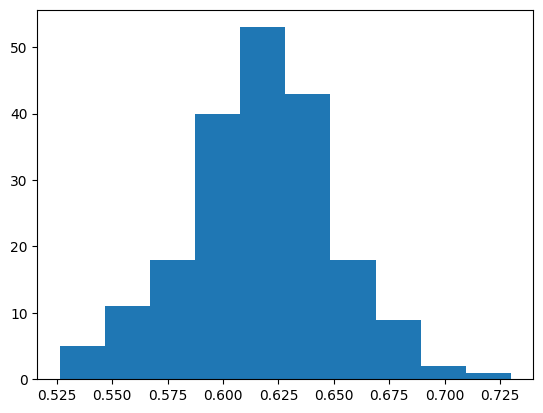

The mean value of theta is 0.616
The standard error of the theta is 0.033


In [14]:
# automatically generate B bootstrap samples
B = 200

theta = []

for i in range(B):
    bstrap_x = np.random.choice(x_return, size=n)
    bstrap_y = np.random.choice(y_return, size=n)

    theta.append(compute_theta(bstrap_x,bstrap_y))

import matplotlib.pyplot as plt

plt.hist(theta)
plt.show()

print(f'The mean value of theta is {np.mean(theta):.3f}')
print(f'The standard error of the theta is {np.std(theta):.3f}')

## <b>🎯Feature Selection</b>

<h2 style="color:blue">Linear Model Selection (Subset Selection)</h2>

In [15]:
# %Matplotlib inline
# It is a magic function that renders the figure in a notebook (instead of displaying a dump of the figure object). A simple Matplotlib tutorial is found here data-blogger.com/2017/11/15/…. – www.data-blogger.com
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools
import time

<h3 style="color:#86ADDC">The best subset selection</h3>

In [16]:
credit_data = pd.read_csv('Credit.csv')
credit_data.head(5)

,Index,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [17]:
credit_data_2 = pd.get_dummies(credit_data[['Gender', 'Student', 'Married','Ethnicity']])
credit_data_2.head()

,Gender_Female,Gender_Male,Student_No,Student_Yes,Married_No,Married_Yes,Ethnicity_African American,Ethnicity_Asian,Ethnicity_Caucasian
0,False,True,True,False,False,True,False,False,True
1,True,False,False,True,False,True,False,True,False
2,False,True,True,False,True,False,False,True,False
3,True,False,True,False,True,False,False,True,False
4,False,True,True,False,False,True,False,False,True


In [18]:
y = credit_data.Balance

# Drop the column with the independent variable (Balance), and columns for which we created dummy variables
X_ = credit_data.drop(['Index', 'Balance', 'Gender', 'Student', 'Married', 'Ethnicity'], axis=1).astype('float64')

# Define the feature set X.
X = pd.concat([X_, credit_data_2[['Gender_Female', 'Student_Yes', 'Married_Yes', 'Ethnicity_African American', 'Ethnicity_Asian', 'Ethnicity_Caucasian']]], axis=1)
X.head()

,Income,Limit,Rating,Cards,Age,Education,Gender_Female,Student_Yes,Married_Yes,Ethnicity_African American,Ethnicity_Asian,Ethnicity_Caucasian
0,14.891,3606.0,283.0,2.0,34.0,11.0,False,False,True,False,False,True
1,106.025,6645.0,483.0,3.0,82.0,15.0,True,True,True,False,True,False
2,104.593,7075.0,514.0,4.0,71.0,11.0,False,False,False,False,True,False
3,148.924,9504.0,681.0,3.0,36.0,11.0,True,False,False,False,True,False
4,55.882,4897.0,357.0,2.0,68.0,16.0,False,False,True,False,False,True


In [19]:
def FitSubsetModel(set_of_predictors):
    # Add a constant term beta_0 to the predictor variable
    X1 = sm.add_constant(X[list(set_of_predictors)])

    X1 = X1.astype(float)   # ensure pure float array
    # Fit model on set_of_predictors
    model = sm.OLS(y,X1).fit()
    # Calculate SSE
    SSE = ((model.predict(X1) - y) ** 2).sum()
    return {"model":model, "SSE":SSE}

In [20]:
def SelectBest(k):

    tic = time.time()

    results = []

    for com_of_subset_models in itertools.combinations(X.columns, k):
        results.append(FitSubsetModel(com_of_subset_models))

    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)

    # Choose the model with the lowest SSE
    best_model = models.loc[models['SSE'].argmin()]

    toc = time.time()
    print("Processed", models.shape[0], "models on", k, "predictors in", (toc-tic), "seconds.")

    # Return the best model, along with some other useful information about the model
    return best_model

In [21]:
# Could take quite awhile to complete...

models_best = pd.DataFrame(columns=["SSE", "model"])

tic = time.time()
for i in range(1, len(X.columns)+1):
    models_best.loc[i] = SelectBest(i)

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")

Processed 12 models on 1 predictors in 0.05015993118286133 seconds.
Processed 66 models on 2 predictors in 0.17842435836791992 seconds.
Processed 220 models on 3 predictors in 0.6026167869567871 seconds.
Processed 495 models on 4 predictors in 1.5962517261505127 seconds.
Processed 792 models on 5 predictors in 2.4484994411468506 seconds.
Processed 924 models on 6 predictors in 3.294041872024536 seconds.
Processed 792 models on 7 predictors in 3.3238790035247803 seconds.
Processed 495 models on 8 predictors in 1.8435580730438232 seconds.
Processed 220 models on 9 predictors in 0.804551362991333 seconds.
Processed 66 models on 10 predictors in 0.24900150299072266 seconds.
Processed 12 models on 11 predictors in 0.04788970947265625 seconds.
Processed 1 models on 12 predictors in 0.004419088363647461 seconds.
Total elapsed time: 14.520231485366821 seconds.


In [22]:
# If we sum up the number of models computed, it should equal to 2^12.
print(1+12+66+220+495+792+924+792+495+220+66+12+1)
print(2 ** 12)

4096
4096


In [23]:
# we can print out the SSE of the best model among different number of predictors
print(models_best)

                SSE                                              model
1   21435122.032733  <statsmodels.regression.linear_model.Regressio...
2    10532541.29017  <statsmodels.regression.linear_model.Regressio...
3    4227219.310607  <statsmodels.regression.linear_model.Regressio...
4    3915058.475097  <statsmodels.regression.linear_model.Regressio...
5    3866091.205862  <statsmodels.regression.linear_model.Regressio...
6    3821619.669694  <statsmodels.regression.linear_model.Regressio...
7    3810758.772869  <statsmodels.regression.linear_model.Regressio...
8    3800968.732466  <statsmodels.regression.linear_model.Regressio...
9    3794144.761429  <statsmodels.regression.linear_model.Regressio...
10   3789708.933317  <statsmodels.regression.linear_model.Regressio...
11   3786730.190678  <statsmodels.regression.linear_model.Regressio...
12   3786730.190678  <statsmodels.regression.linear_model.Regressio...


In [24]:
# we can print out the details of the best model for different number of predictors
# This output means that the best 2-predictor model contains Income and Limit.
d = 8
print(models_best.loc[d, "model"].summary())

                            OLS Regression Results                            
Dep. Variable:                Balance   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     1036.
Date:                Tue, 04 Aug 2026   Prob (F-statistic):          7.56e-258
Time:                        09:14:14   Log-Likelihood:                -2399.4
No. Observations:                 400   AIC:                             4817.
Df Residuals:                     391   BIC:                             4853.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [25]:
# Instead of printing out the whole output, we can choose to print only the useful information to display
models_best.loc[2, "model"].rsquared

np.float64(0.8751179476994355)

In [26]:
# Let's now compare and the select the best model
# Gets the second element from each row ('model') and pulls out its rsquared attribute
models_best.apply(lambda row: row[1].rsquared, axis=1)


/tmp/ipykernel_6539/3486177141.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  models_best.apply(lambda row: row[1].rsquared, axis=1)


,0
1,0.745848
2,0.875118
3,0.949879
4,0.953580
5,0.954161
6,0.954688
7,0.954817
8,0.954933
9,0.955014
10,0.955066


As expected, the  R2 statistic increases monotonically as more variables are included.


Plotting RSS, adjusted  R2
 , AIC, and BIC for all of the models at once will help us decide which model to select. Note the type="l" option tells R to connect the plotted points with lines:

/tmp/ipykernel_6539/2485750967.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rsquared_adj = models_best.apply(lambda row: row[1].rsquared_adj, axis=1)
/tmp/ipykernel_6539/2485750967.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  aic = models_best.apply(lambda row: row[1].aic, axis=1)
/tmp/ipykernel_6539/2485750967.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bic = models_best.apply(lambda row: row[1].bic, axis=1

Text(0, 0.5, 'BIC')

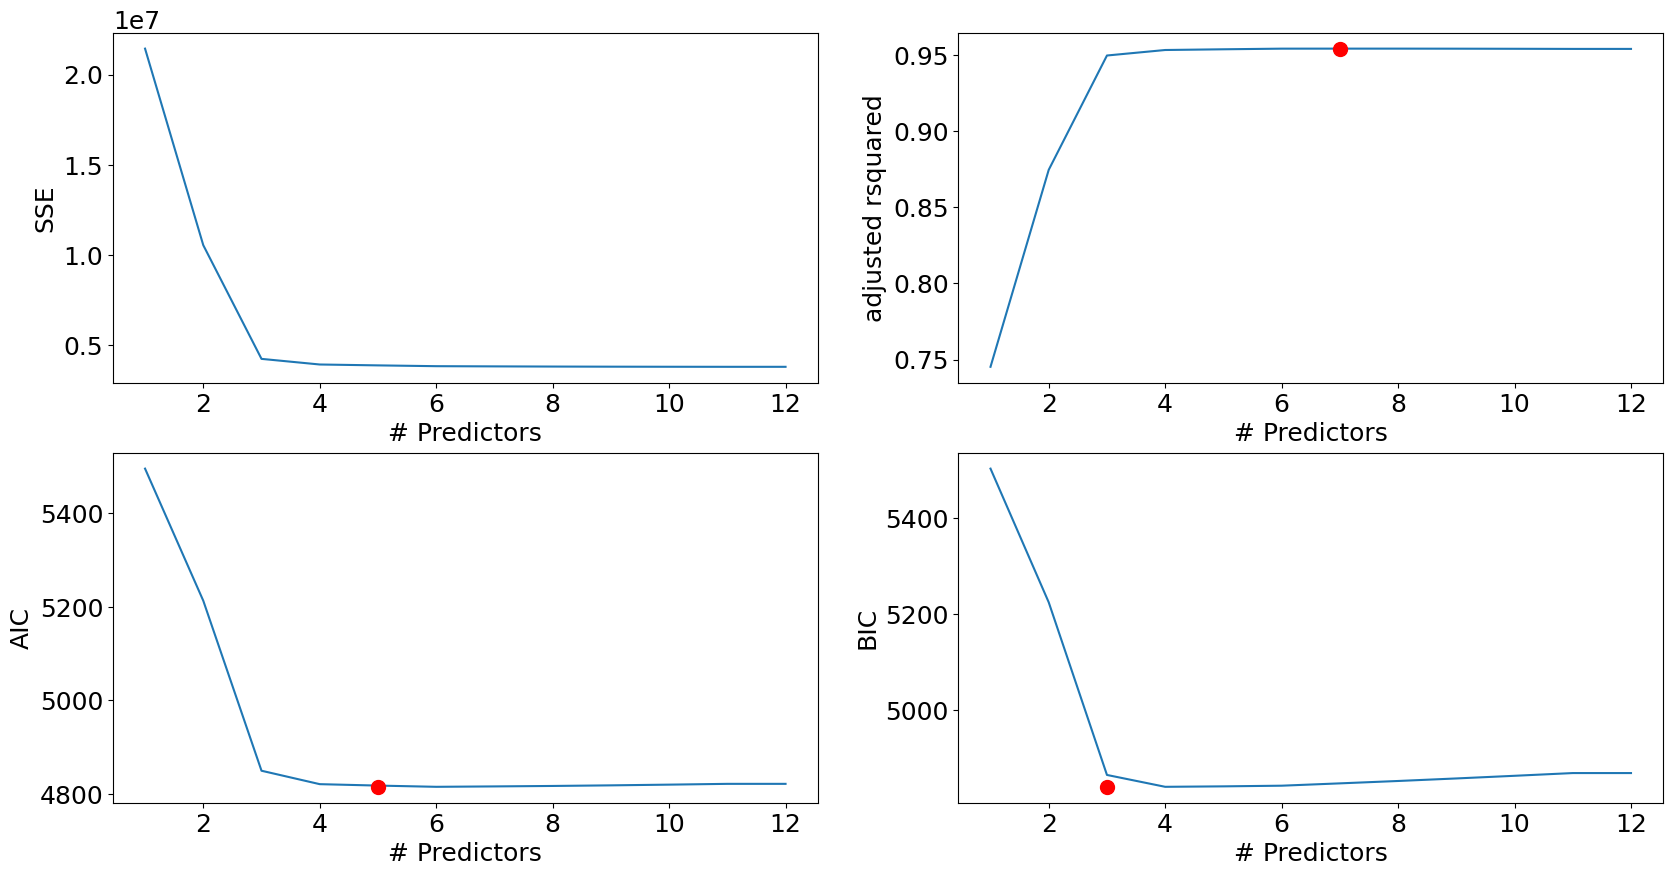

In [27]:
plt.figure(figsize=(20,10))
plt.rcParams.update({'font.size': 18, 'lines.markersize': 10})

# Set up a 2x2 grid so we can look at 4 plots at once
plt.subplot(2, 2, 1)

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector
plt.plot(models_best["SSE"])
plt.xlabel('# Predictors')
plt.ylabel('SSE')

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector

rsquared_adj = models_best.apply(lambda row: row[1].rsquared_adj, axis=1)

plt.subplot(2, 2, 2)
plt.plot(rsquared_adj)
plt.plot(rsquared_adj.argmax(), rsquared_adj.max(), "or")
plt.xlabel('# Predictors')
plt.ylabel('adjusted rsquared')

# We'll do the same for AIC and BIC, this time looking for the models with the SMALLEST statistic
aic = models_best.apply(lambda row: row[1].aic, axis=1)

plt.subplot(2, 2, 3)
plt.plot(aic)
plt.plot(aic.argmin(), aic.min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('AIC')

bic = models_best.apply(lambda row: row[1].bic, axis=1)

plt.subplot(2, 2, 4)
plt.plot(bic)
plt.plot(bic.argmin(), bic.min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('BIC')

<h2 style="color:#86ADDC">Forward Selection</h2>

In [28]:
def FitModel(set_of_predictors):
    # Fit model on set_of_predictors
    model = sm.OLS(y,X[list(set_of_predictors)].astype(float)).fit()
    # Calculate SSE
    SSE = ((model.predict(X[list(set_of_predictors)]) - y) ** 2).sum()
    return {"model":model, "SSE":SSE}

def forward(predictors):

    # Pull out predictors we still need to process
    remaining_predictors = [p for p in X.columns if p not in predictors]

    tic = time.time()

    results = []

    for p in remaining_predictors:
        results.append(FitModel(predictors+[p]))

    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)

    # Choose the model with the lowest RSS
    best_model = models.loc[models['SSE'].argmin()]

    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)+1, "predictors in", (toc-tic), "seconds.")

    # Return the best model, along with some other useful information about the model
    return best_model

In [29]:
models_fwd = pd.DataFrame(columns=["SSE", "model"])

tic = time.time()
predictors = []

for i in range(1,len(X.columns)+1):
    models_fwd.loc[i] = forward(predictors)
    predictors = models_fwd.loc[i]["model"].model.exog_names
    # predictors.remove('const')
    print(predictors)

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")

Processed  12 models on 1 predictors in 0.024623870849609375 seconds.
['Limit']
Processed  11 models on 2 predictors in 0.022785663604736328 seconds.
['Limit', 'Income']
Processed  10 models on 3 predictors in 0.027361154556274414 seconds.
['Limit', 'Income', 'Education']
Processed  9 models on 4 predictors in 0.02917313575744629 seconds.
['Limit', 'Income', 'Education', 'Student_Yes']
Processed  8 models on 5 predictors in 0.020228862762451172 seconds.
['Limit', 'Income', 'Education', 'Student_Yes', 'Age']
Processed  7 models on 6 predictors in 0.017949581146240234 seconds.
['Limit', 'Income', 'Education', 'Student_Yes', 'Age', 'Gender_Female']
Processed  6 models on 7 predictors in 0.015775442123413086 seconds.
['Limit', 'Income', 'Education', 'Student_Yes', 'Age', 'Gender_Female', 'Married_Yes']
Processed  5 models on 8 predictors in 0.013322591781616211 seconds.
['Limit', 'Income', 'Education', 'Student_Yes', 'Age', 'Gender_Female', 'Married_Yes', 'Ethnicity_Caucasian']
Processed  

In [30]:
print(models_fwd)

                SSE                                              model
1   28284986.044848  <statsmodels.regression.linear_model.Regressio...
2   21593382.928211  <statsmodels.regression.linear_model.Regressio...
3    13469879.75724  <statsmodels.regression.linear_model.Regressio...
4    6993371.313434  <statsmodels.regression.linear_model.Regressio...
5      5936228.0802  <statsmodels.regression.linear_model.Regressio...
6    5825591.525225  <statsmodels.regression.linear_model.Regressio...
7    5733492.936554  <statsmodels.regression.linear_model.Regressio...
8    5690355.647433  <statsmodels.regression.linear_model.Regressio...
9    5564550.020028  <statsmodels.regression.linear_model.Regressio...
10   4241826.149215  <statsmodels.regression.linear_model.Regressio...
11   3839043.903239  <statsmodels.regression.linear_model.Regressio...
12   3786730.190678  <statsmodels.regression.linear_model.Regressio...


In [31]:
d = 2
print(models_fwd.loc[d,'model'].summary())

                                 OLS Regression Results                                
Dep. Variable:                Balance   R-squared (uncentered):                   0.888
Model:                            OLS   Adj. R-squared (uncentered):              0.887
Method:                 Least Squares   F-statistic:                              1575.
Date:                Tue, 04 Aug 2026   Prob (F-statistic):                   8.42e-190
Time:                        09:14:15   Log-Likelihood:                         -2746.9
No. Observations:                 400   AIC:                                      5498.
Df Residuals:                     398   BIC:                                      5506.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

<h2 style="color:#86ADDC">Backward Selection</h2>

In [32]:
def backward(predictors):

    tic = time.time()

    results = []

    for combo in itertools.combinations(predictors, len(predictors)-1):
        results.append(FitModel(combo))

    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)

    # Choose the model with the highest RSS
    best_model = models.loc[models['SSE'].argmin()]

    toc = time.time()
    print("Processed ", models.shape[0], "models on", len(predictors)-1, "predictors in", (toc-tic), "seconds.")

    # Return the best model, along with some other useful information about the model
    return best_model

In [33]:
models_bwd = pd.DataFrame(columns=["SSE", "model"], index = range(1,len(X.columns)))

tic = time.time()
predictors = X.columns

while(len(predictors) > 1):
    models_bwd.loc[len(predictors)-1] = backward(predictors)
    predictors = models_bwd.loc[len(predictors)-1]["model"].model.exog_names
    # predictors.remove('const')

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")

Processed  12 models on 11 predictors in 0.037468671798706055 seconds.
Processed  11 models on 10 predictors in 0.03171730041503906 seconds.
Processed  10 models on 9 predictors in 0.027009248733520508 seconds.
Processed  9 models on 8 predictors in 0.023987293243408203 seconds.
Processed  8 models on 7 predictors in 0.022886037826538086 seconds.
Processed  7 models on 6 predictors in 0.017474651336669922 seconds.
Processed  6 models on 5 predictors in 0.018294811248779297 seconds.
Processed  5 models on 4 predictors in 0.014512777328491211 seconds.
Processed  4 models on 3 predictors in 0.009728431701660156 seconds.
Processed  3 models on 2 predictors in 0.006714582443237305 seconds.
Processed  2 models on 1 predictors in 0.004087209701538086 seconds.
Total elapsed time: 0.22087311744689941 seconds.


In [34]:
print(models_bwd.loc[6, 'model'].summary())

                            OLS Regression Results                            
Dep. Variable:                Balance   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     1465.
Date:                Tue, 04 Aug 2026   Prob (F-statistic):          5.44e-252
Time:                        09:14:15   Log-Likelihood:                -2424.3
No. Observations:                 400   AIC:                             4861.
Df Residuals:                     394   BIC:                             4885.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Income              